In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.insert(0, '../src/')

from models.XPLORE import XPLORE, posteriors2coordinates
from utils.metrics import NearestCandidates
import utils.visualization as vis

# Questions

In [2]:
dataset = pd.read_excel('~/Data/Smartvote/election23/23_ch_nr-questions_de-fr-it-en.xlsx')
categories = pd.read_excel('~/Data/Smartvote/election23/23_ch_nr-question categories.xlsx', index_col=0)
questions = dataset.filter(['ID_question','question_DE','question_EN','rapide', 'category']).set_index('ID_question')
questions.category = questions.category.map(categories.text_EN.to_dict())
questions

,question_DE,question_EN,rapide,category
ID_question,,,,
32214,Befürworten Sie eine Erhöhung des Rentenalters...,Do you support an increase in the retirement a...,1,Welfare state & family
32215,Soll der Staat mehr Mittel für die Krankenkass...,Should the federal government allocate more fu...,1,Welfare state & family
32216,Bei Ehepaaren ist die Höhe der Rente heute auf...,"For married couples, the pension is currently ...",0,Welfare state & family
32217,Im Rahmen der BVG-Reform sollen die Renten gek...,As part of the reform of the BVG (occupational...,0,Welfare state & family
32218,Soll die bezahlte Elternzeit von heute 14 Woch...,Should paid parental leave be increased beyond...,0,Welfare state & family
...,...,...,...,...
32284,"Soll der Bund im Bereich ""Öffentlicher Verkehr...",Should the federal government spend more or le...,0,Federal budget
32285,"Soll der Bund im Bereich ""Strassenverkehr (mot...",Should the federal government spend more or le...,0,Federal budget
32286,"Soll der Bund im Bereich ""Öffentliche Sicherhe...",Should the federal government spend more or le...,0,Federal budget


In [9]:
questions = questions.replace(r' \[BePart question\]', '', regex=True)
questions = questions.replace(r' \[BePart-Frage\]', '', regex=True)
questions = questions.replace(r' or less', '', regex=True)
questions = questions.replace(r' oder weniger', '', regex=True)

In [10]:
questions.to_csv('../data/questions.csv')

# Candidates

In [3]:
dataset = pd.read_excel('~/Data/Smartvote/election23/23_ch_nr_candidates_de_2024_03_06.xlsx', index_col=0)
parties = dataset.loc[dataset.canton==1].groupby("party_short").ID_candidate.count().sort_values()
parties

party_short
JSVP          33
JUSO          33
JG            36
JEVP          36
JFS           36
JGLP          36
PdA           36
FDP           37
EDU           55
EVP           74
JM            76
Parteilos     77
Grüne         91
SP           107
SVP          133
Die Mitte    140
GLP          144
Übrige       161
Name: ID_candidate, dtype: int64

In [4]:
party_mapping = {
    'EVP': 'EVP',
    'Grüne': 'Grüne',
    'FDP': 'FDP',
    'SVP': 'SVP',
    'SP': 'SP',
    'GLP': 'GLP',
    'Die Mitte': 'Mitte',
    'JEVP': 'EVP',
    'JG': 'Grüne',
    'JFS': 'FDP',
    'JSVP': 'SVP',
    'JUSO': 'SP',
    'JGLP': 'GLP',
    'JM': 'Mitte',
    'EDU': 'EDU',
    'PdA': 'Übrige',
    'Parteilos': 'Übrige',
    'Übrige': 'Übrige',
}

In [5]:
idx_mask = (dataset.ID_district == 952) & (dataset.N_answers == 75)
candidates = dataset.loc[idx_mask].filter(['party_short'])
candidates['color'] = candidates.party_short.map(vis.party_colors)
candidates['list'] =  candidates.party_short.map(party_mapping)
candidates.index.name = 'candidates'
candidates.columns.name = 'questions'
candidates.to_csv('../data/candidates.csv')
print(candidates.isna().any().any())
candidates

False


questions,party_short,color,list
candidates,,,
9,JFS,#0000FF,FDP
16,GLP,#32CD32,GLP
25,JEVP,#FFA500,EVP
30,Übrige,#888888,Übrige
31,SP,#FF0000,SP
...,...,...,...
5915,SVP,#4F7942,SVP
5918,JM,#C56C46,Mitte
5921,Die Mitte,#C56C46,Mitte


In [6]:
comments = dataset.columns.str.startswith('comment_')
comments = dataset.loc[idx_mask, comments]
comments.to_csv('../data/candidates_comments.csv')
comments#.loc[5915,'comment_32216']

,comment_32214,comment_32215,comment_32216,comment_32217,comment_32218,comment_32219,comment_32220,comment_32221,comment_32222,comment_32223,...,comment_32279,comment_32280,comment_32281,comment_32282,comment_32283,comment_32284,comment_32285,comment_32286,comment_32287,comment_32288
9,Durch die schrittweise Erhöhung des Rentenalte...,NaN,Ehepaare sollten individuell besteuert werden ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Eine Erhöhung des Rentenalters auf 67 Jahre be...,Die steigenden Krankenkassenprämien belasten v...,Die Begrenzung der AHV-Rente für Ehepaare auf ...,Die Senkung des Mindestumwandlungssatzes im BV...,Ich unterstütze die Ausweitung der bezahlten E...,Der gemeinnützige Wohnungsbau spielt eine ents...,"Ich lehne eine Impfpflicht für Kinder ab, da n...",Ich befürworte die Einführung einer Abgabe auf...,"Ich bin eher dagegen, die Mindestfranchise zu ...","Ja, ich befürworte eine stärkere Begrenzung de...",...,Ich betrachte die Frage differenziert. Grundsä...,"Ich teile die Ansicht, dass ein stärkerer Umwe...",Ich fokussiere mich auf die Qualität der Ausga...,Ich stehe klar hinter einer deutlichen Erhöhun...,Ich unterstütze eine verstärkte Förderung der ...,"Ich bin der Ansicht, dass der öffentliche Verk...",Ich bevorzuge eine Reduzierung der Ausgaben im...,"Ich bin der Auffassung, dass im Bereich der öf...",Ich unterstütze eine Erhöhung der Ausgaben im ...,"Ich neige dazu, die Ausgaben im Bereich der En..."
25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Beides ist gleich wichtig.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN,Die Empfehlungen des Impfplans unterstütze ich...,NaN,NaN,Statt der Schwächung des Bundesrats sollte die...,...,NaN,NaN,NaN,NaN,"Für nachhaltige Landwirtschaft, insbesondere d...",NaN,NaN,Das hängt von der Auslegung des Begriffs ab. F...,NaN,NaN
31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5915,Wir werden immer älter und sind oft auch noch ...,Diese Pflästerlipolitik muss gestoppt werden. ...,"Es ist stossend, wenn Ehepaare gegenüber nicht...","es ist wichtiger eine sichere Rente zu haben, ...",Elternsein beschränkt sich nicht auf ein paar ...,NaN,"Impfen ist wichtig, aber nicht alle sehen das ...",Erwachsene Menschen sollten auch verantwortung...,Die Kosten laufen sonst völlig aus dem Ruder -...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5918,NaN,NaN,NaN,NaN,Neben der Mindestzeit vom 8 Wochen für die Mut...,Er soll stattdessen gezielt einkommensschwache...,Eine Impfpflicht ist ein starker Eingriff in d...,"Da wir ein soziales Gesundheitssystem haben, w...",NaN,NaN,...,NaN,Richtiger Umweltschutz ist langfristig Wirtsch...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5921,NaN,Besser wäre die Prämienbefreiung für Kinder.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
pattern = r'^answer_\d+$'  # ^ and $ ensure no characters before or after the pattern
answers  = dataset.loc[idx_mask].filter(regex=pattern)/100
answers.columns = answers.columns.to_series().str.split('_',expand=True)[1]
answers.to_csv('../data/candidates_reactions.csv')
answers

1,32214,32215,32216,32217,32218,32219,32220,32221,32222,32223,...,32279,32280,32281,32282,32283,32284,32285,32286,32287,32288
9,1.00,0.25,1.00,1.00,0.00,0.25,1.00,0.00,0.75,0.00,...,0.17,0.17,0.25,1.00,0.00,0.75,0.25,0.50,0.50,0.25
16,0.25,0.75,0.75,0.00,0.75,1.00,0.00,1.00,0.00,1.00,...,0.33,0.83,0.50,0.75,0.75,0.50,0.25,0.75,0.75,0.00
25,1.00,1.00,1.00,0.00,0.00,0.75,0.00,0.25,0.00,0.25,...,0.33,0.67,0.50,0.75,0.50,0.75,0.50,0.50,0.50,0.50
30,0.00,1.00,1.00,0.00,1.00,1.00,0.25,0.75,0.00,0.00,...,0.00,1.00,1.00,1.00,0.50,1.00,0.00,0.50,0.00,1.00
31,0.00,1.00,0.25,0.00,1.00,1.00,0.25,0.25,0.00,0.00,...,0.00,1.00,0.75,1.00,0.25,1.00,0.00,0.50,0.25,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5915,0.75,0.00,0.75,0.75,0.00,0.00,0.00,0.00,0.75,0.75,...,0.83,0.00,0.00,0.25,0.75,0.25,0.75,0.75,0.75,0.00
5918,0.75,0.75,1.00,0.75,0.75,0.00,0.00,1.00,0.75,0.75,...,0.33,0.33,0.50,0.75,0.25,0.50,0.50,0.50,0.50,0.75
5921,1.00,0.75,0.75,1.00,1.00,0.25,0.00,0.00,0.25,0.00,...,0.17,1.00,0.75,0.75,0.25,0.25,0.50,0.50,0.75,0.50
5922,0.00,1.00,1.00,0.00,1.00,1.00,0.00,1.00,0.00,0.25,...,0.00,1.00,0.75,1.00,0.50,1.00,0.00,0.50,0.00,1.00


### Party means

In [10]:
means = answers.set_index(candidates.list).groupby(level=0).mean().T
means.to_csv('../data/party_means.csv')
means

list,EDU,EVP,FDP,GLP,Grüne,Mitte,SP,SVP,Übrige
1,,,,,,,,,
32214,0.522222,0.465054,0.979839,0.781046,0.185268,0.503401,0.022222,0.558962,0.278409
32215,0.400000,0.857527,0.108871,0.645425,0.917411,0.675170,0.987037,0.110849,0.615057
32216,0.716667,0.943548,0.673387,0.522876,0.859375,0.933673,0.681481,0.497642,0.784091
32217,0.316667,0.588710,0.899194,0.754902,0.069196,0.693878,0.038889,0.669811,0.264205
32218,0.277778,0.801075,0.197581,0.848039,0.968750,0.744898,0.979630,0.073113,0.569602
...,...,...,...,...,...,...,...,...,...
32284,0.505556,0.717742,0.544355,0.674837,0.919643,0.639456,0.922222,0.408019,0.599432
32285,0.594444,0.325269,0.572581,0.245098,0.064732,0.481293,0.138889,0.686321,0.325284
32286,0.638889,0.543011,0.633065,0.511438,0.406250,0.556122,0.405556,0.719340,0.438920


In [11]:
stds = answers.set_index(candidates.list).groupby(level=0).std().T
stds.to_csv('../data/party_stds.csv')
stds.head()

list,EDU,EVP,FDP,GLP,Grüne,Mitte,SP,SVP,Übrige
1,,,,,,,,,
32214,0.379975,0.350836,0.068628,0.261763,0.326643,0.382613,0.103424,0.406131,0.379721
32215,0.366959,0.237165,0.124967,0.275977,0.202430,0.301842,0.055638,0.226464,0.430830
32216,0.355956,0.165376,0.340530,0.367647,0.276279,0.173912,0.304551,0.435747,0.322228
32217,0.374621,0.364239,0.214532,0.342291,0.190453,0.380154,0.149210,0.403183,0.387958
32218,0.370128,0.322522,0.310793,0.228041,0.142867,0.322487,0.126121,0.228783,0.452516


### Party Percentages

In [15]:
results = pd.read_csv('~/Data/Smartvote/election23/chart-23-table-results-national-council-election-zh-de.csv', decimal=',')
results

,Partei,Mandate,Mandate (Veränderung),Stimmen%,Stimmen% (Veränderung),Frauen%,Frauen% (Veränderung)
0,FDP,5,-,12.45,-1.21,40.00,-
1,Mitte,3,+3,8.15,8.15,66.67,"+66,67"
2,SP,8,+1,21.14,3.83,75.00,"+3,57"
3,SVP,10,-,27.35,0.65,20.00,-
4,EVP,1,-,2.84,-0.46,0.00,-
5,GLP,4,-2,12.37,-1.63,75.00,"+8,33"
6,PdA/Sol.,0,-,0.30,-0.01,0.00,-
7,FGA,0,-,0.97,-0.64,0.00,-
8,GRÜNE,4,-1,9.93,-4.15,50.00,-10
9,SD,0,-,0.10,-0.09,0.00,-


In [16]:
# Group parties with zero mandates under 'Übrige'
results.loc[results['Mandate'] == 0, 'Partei'] = 'Übrige'
results['Partei'] = results['Partei'].replace('GRÜNE', 'Grüne')
results_clean = results.groupby('Partei')['Stimmen%'].sum()
results_clean.to_csv('../data/results_zh.csv')
results_clean

Partei
EDU        1.49
EVP        2.84
FDP       12.45
GLP       12.37
Grüne      9.93
Mitte      8.15
SP        21.14
SVP       27.35
Übrige     4.27
Name: Stimmen%, dtype: float64

# Users

In [38]:
file_path = '~/Data/Smartvote/election23/sv23_nr_voter/sv23 Voters-NR 2024-03-14.csv'
chunk_size = 50000  # You can adjust the number of rows depending on your system's memory
users = []
counter = 1

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    columns_to_keep = [col for col in chunk.columns if col.startswith(('answer_', 'age', 'gender', 'pref_party', 'position', 'rec', 'voter'))]
    chunk = chunk.loc[(chunk.districtID == 952)  # From Zurich
                    & (chunk.N_answers == 75), # Complete answers 
                    columns_to_keep
                    ]
    users.append(chunk)  # Optional: Append processed chunks to a list if needed for further analysis
    print(f'Loaded chunk: {counter}')
    counter+=1

users = pd.concat(users)
users

/var/folders/2k/vrhx9qhx53b7kfprkkj8l5km0000gn/T/ipykernel_20144/2424563266.py:9: DtypeWarning: Columns (10,23,24,28,36,40,53,58,65,99,100,104,112,116,129,134,141,174,175,176,177,178,179,180,181,186,187,188,1528) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):


Loaded chunk: 1


/var/folders/2k/vrhx9qhx53b7kfprkkj8l5km0000gn/T/ipykernel_20144/2424563266.py:9: DtypeWarning: Columns (10,23,36,40,49,53,99,112,116,125,129,174,175,176,177,178,179,180,181,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,1528,1529,1530,1531,1532,1533,1534,1535,1536,1537,1538,1539,1540,1541,1542,1543,1544,1545,1546,1547) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):


Loaded chunk: 2


/var/folders/2k/vrhx9qhx53b7kfprkkj8l5km0000gn/T/ipykernel_20144/2424563266.py:9: DtypeWarning: Columns (10,23,24,32,36,37,40,49,53,54,55,99,100,108,112,113,116,125,129,130,131,174,175,176,177,178,179,180,181,186,187,188,1528) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):


...

/var/folders/2k/vrhx9qhx53b7kfprkkj8l5km0000gn/T/ipykernel_20144/2424563266.py:9: DtypeWarning: Columns (10,23,24,36,49,53,99,100,112,125,129,174,175,176,177,178,179,180,181,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,1528,1529,1530,1531,1532,1533,1534,1535,1536,1537,1538,1539,1540,1541,1542,1543,1544,1545,1546,1547) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):


Loaded chunk: 33


/var/folders/2k/vrhx9qhx53b7kfprkkj8l5km0000gn/T/ipykernel_20144/2424563266.py:9: DtypeWarning: Columns (10,23,49,99,125,174,175,176,177,178,179,180,181,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,1528,1529,1530,1531,1532,1533,1534,1535,1536,1537,1538,1539,1540,1541) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size):


Loaded chunk: 34


,recID,voterID,recTIME,recTYPE,age,gender,position,pref_party,answer_32214,answer_32215,...,answer_32279,answer_32280,answer_32281,answer_32282,answer_32283,answer_32284,answer_32285,answer_32286,answer_32287,answer_32288
7,e7901c34-bc94-4262-8f72-33c95de5ca36,1e82f9b0-43d1-11ee-bc39-fd4163c77323,"26.08.2023, 05:38:02",1,,,,,100,0,...,100,33,25,75,75,0,75,100,75,0
26,f514d278-7e71-421f-aead-fed4e34979d6,db313790-43ed-11ee-9617-b75fd6480578,"26.08.2023, 08:57:06",1,,,,,100,75,...,33,83,50,75,50,100,25,50,25,50
28,ee6bc2f8-a1eb-4362-8405-9efcac317fdb,286cd5e0-428c-11ee-bcbb-ebbe60cc4955,"26.08.2023, 08:55:07",1,30,m,5,14,0,100,...,100,33,75,75,0,75,75,50,0,0
38,e6de32a2-bdd6-4027-8b62-c7efd9659745,ade894ca-03fb-4cd2-839a-36b154d0397c,"26.08.2023, 06:29:21",2,39,m,4,,25,100,...,50,67,100,100,50,100,25,100,25,75
47,f55a907c-eb06-4e6e-a2b2-bf0686db396a,956c2c50-43da-11ee-b28c-b5843b0b24db,"26.08.2023, 06:42:45",1,,,,,0,100,...,100,100,100,50,50,50,25,50,25,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1662423,cff2b8bf-d218-4b0b-9add-96fc56b708cb,b99334f0-4c24-11ee-a7ee-097a0a293644,"05.09.2023, 19:59:41",1,37,m,2,4,0,100,...,0,100,100,100,75,50,75,75,100,75
1662448,d15167c7-2993-4df5-867b-efe7e8e35d51,22319930-4c29-11ee-a362-0b20a422c30f,"05.09.2023, 20:28:37",2,39,m,,,75,25,...,100,33,0,75,25,100,100,75,75,0
1662475,d8e132d0-6593-4f93-8cb7-17296df0091b,d73a9730-4c2b-11ee-b581-874767424f0d,"05.09.2023, 21:20:41",1,,,,,75,100,...,17,100,100,100,25,100,0,50,0,75
1662477,d88f86f2-fa4d-4525-8362-85137493f286,f9417540-4c2d-11ee-ae95-0db98918ba3f,"05.09.2023, 21:25:30",1,37,m,1,13,0,100,...,0,67,100,100,25,100,25,25,0,25


In [62]:
users.recTIME = pd.to_datetime(users.recTIME)
users = users.sort_values(by='recTIME', ascending=True).drop_duplicates(subset='voterID', keep='first')
users.to_csv('../data/users_zh.csv')
users

,recID,voterID,recTIME,recTYPE,age,gender,position,pref_party,answer_32214,answer_32215,...,answer_32279,answer_32280,answer_32281,answer_32282,answer_32283,answer_32284,answer_32285,answer_32286,answer_32287,answer_32288
1469569,4681d305-7eda-4b37-944e-af50216490c5,6a5d39f0-4114-11ee-8ef5-41c093326d11,2023-08-23 09:55:05,1,21,m,4,6,100,0,...,17,67,50,75,50,75,25,50,50,50
674490,aaadb9f6-e73a-42f9-85a4-2ba53d50a197,f6a3603e-50dd-44df-9016-4b5890cf69cd,2023-08-23 10:18:39,1,45,m,4,,25,25,...,50,67,50,75,0,100,0,50,25,75
674508,a1fcf989-e7ec-4c66-addd-d307cc853c2f,ce0227b0-419e-11ee-94e1-9df5cc536f2e,2023-08-23 10:22:16,1,,,,,100,0,...,67,0,25,75,50,50,75,75,100,0
348489,dbd0416f-953b-442f-b40a-71476cbd2143,c0cf7d20-6b97-4741-8962-8dc786efe1fd,2023-08-23 10:28:14,1,31,m,3,,0,75,...,17,67,50,75,25,100,0,50,75,50
1184947,0e1f9c7c-057f-4b32-8452-1906c8281d52,1b0b4dd2-ada5-4aef-b4ea-c4b7c77d1649,2023-08-23 10:28:47,1,25,f,5,2,100,0,...,67,67,50,75,50,75,50,50,0,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906001,4a5ace71-661c-406e-9557-b5c2e04be6c0,46f3f770-7430-11ee-be93-5f8b4dcbbcdd,2023-10-26 19:47:19,1,,m,7,14,100,0,...,83,17,0,75,50,50,50,50,100,50
856010,ffb70fbb-e06e-4157-8823-aa34247f99d4,4ad15340-5524-11ee-adaa-01cefb9c5e54,2023-10-26 21:02:45,1,,,,,100,0,...,17,33,0,0,0,25,0,75,75,0
906061,73b8da80-adf6-4aa4-b211-68f7321e39c6,61e09430-73ef-11ee-b458-6b27671325bd,2023-10-26 21:30:30,1,,,6,,75,100,...,0,100,100,100,25,100,0,0,25,100
60970,b7008293-c954-49b0-9507-a373da2fa909,6960c818-9365-4023-ba01-be0df06bea0c,2023-10-26 21:42:02,2,,,,,25,75,...,100,67,25,75,75,50,75,100,75,25


### Re-Load and preprocess

In [13]:
party_dict = {
    '1': "Mitte",
    '2': "FDP",
    '3': "SVP",
    '4': "SP",
    '5': "Grüne",
    '6': "GLP",
    '7': "BDP",
    '8': "Lega",
    '9': "MCG",
    '10': "EVP",
    '11': "EDU",
    '12': "PdA",
    '13': "AL",
    '14': "Keine",
    '99': "Andere",
    # ' ': "Wert fehlt"
}

users = pd.read_csv('../data/users_zh.csv', index_col=0)
users = users.loc[users.pref_party.isin(party_dict.keys())]
users

,recID,voterID,recTIME,recTYPE,age,gender,position,pref_party,answer_32214,answer_32215,...,answer_32279,answer_32280,answer_32281,answer_32282,answer_32283,answer_32284,answer_32285,answer_32286,answer_32287,answer_32288
1469569,4681d305-7eda-4b37-944e-af50216490c5,6a5d39f0-4114-11ee-8ef5-41c093326d11,2023-08-23 09:55:05,1,21,m,4,6,100,0,...,17,67,50,75,50,75,25,50,50,50
1184947,0e1f9c7c-057f-4b32-8452-1906c8281d52,1b0b4dd2-ada5-4aef-b4ea-c4b7c77d1649,2023-08-23 10:28:47,1,25,f,5,2,100,0,...,67,67,50,75,50,75,50,50,0,50
1125920,9da19a39-2714-4b6e-aedb-6f79f3292d50,c22ddac0-419d-11ee-baa0-f1d1f9b03811,2023-08-23 10:29:19,1,39,m,6,2,100,0,...,33,17,0,75,25,50,75,75,75,25
674521,c0a9301a-a77c-45d7-bdf3-da3c34cdde68,c34bdfd0-419b-11ee-bcd1-fffd0eb06069,2023-08-23 10:46:34,1,18,m,1,5,0,75,...,17,100,100,100,25,100,0,0,0,100
1346591,6af820d8-4ee2-41a6-93cf-0fa68bdc4d5d,508f98ac-397b-4f64-8cb5-e9ea1ed78f6c,2023-08-23 10:56:16,1,,m,5,2,75,25,...,83,17,0,75,75,25,75,75,75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905937,17e16b9f-3dd1-4708-ac1a-be1ce9d4f769,d6b2c580-742b-11ee-8dba-db31bdd8479d,2023-10-26 18:27:10,1,46,f,2,4,75,100,...,17,83,75,75,50,75,25,50,25,75
60849,83e280bc-363a-4c31-9f34-b7dd6f6415cc,af781df0-7429-11ee-b550-a754273e2f1a,2023-10-26 18:39:59,1,42,m,1,4,0,100,...,17,100,100,100,25,75,25,50,25,100
60900,d3d79336-ba1a-42e8-8a75-939ac40a65ce,40ca7aaa-6215-498c-99f8-2e7318856a11,2023-10-26 19:41:15,1,42,m,5,2,100,25,...,0,67,25,100,75,100,0,75,100,25
906001,4a5ace71-661c-406e-9557-b5c2e04be6c0,46f3f770-7430-11ee-be93-5f8b4dcbbcdd,2023-10-26 19:47:19,1,,m,7,14,100,0,...,83,17,0,75,50,50,50,50,100,50


In [14]:
party = users.pref_party.value_counts().to_frame()
party['name'] = party.index.map(party_dict)
party

,count,name
pref_party,,
14,2664,Keine
6,2426,GLP
4,2399,SP
2,1538,FDP
5,1167,Grüne
1,742,Mitte
3,697,SVP
10,211,EVP
13,190,AL


In [15]:
pref_party = users.pref_party.map(party_dict)
pref_party

1469569      GLP
1184947      FDP
1125920      FDP
674521     Grüne
1346591      FDP
           ...  
905937        SP
60849         SP
60900        FDP
906001     Keine
906080        SP
Name: pref_party, Length: 12315, dtype: object

In [16]:
results = pd.read_csv('../data/results_zh.csv', index_col=0)/100
results['voters'] = pref_party.value_counts()
results['size'] = results['voters'] / results['Stimmen%']
results

,Stimmen%,voters,size
Partei,,,
EDU,0.0149,55.0,3691.275168
EVP,0.0284,211.0,7429.577465
FDP,0.1245,1538.0,12353.413655
GLP,0.1237,2426.0,19611.964430
Grüne,0.0993,1167.0,11752.265861
Mitte,0.0815,742.0,9104.294479
SP,0.2114,2399.0,11348.155156
SVP,0.2735,697.0,2548.446069
Übrige,0.0427,NaN,NaN


In [17]:
def sample_voters(row):
    N = int(results['size'].min() * row['Stimmen%'])
    if row.name == 'Übrige':
        return pd.Index([])
    sample = pref_party.loc[pref_party==row.name].sample(n=N)
    return sample.index.values

In [18]:
from itertools import chain
s = results.apply(sample_voters, axis=1)
combined_index = pd.Index(chain.from_iterable(s))
combined_index

Index([ 658746,  137303,  914053, 1592189,  328632,   96406,  823090,  533900,
       1419963,  229473,
       ...
       1176833, 1177109,  240468,  693548,  507106,  881622, 1615439,  749194,
        890220,  174090],
      dtype='int64', length=2436)

In [19]:
pattern = r'^answer_\d+$'  # ^ and $ ensure no characters before or after the pattern
reactions  = users.filter(regex=pattern).sort_index().astype(int)/100
reactions.columns = reactions.columns.to_series().str.split('_',expand=True)[1]
assert not reactions.isna().any().any()
reactions.index.name = 'voter'
reactions.columns.name = 'question'
reactions.to_csv('../data/voters_reactions.csv')
reactions

question,32214,32215,32216,32217,32218,32219,32220,32221,32222,32223,...,32279,32280,32281,32282,32283,32284,32285,32286,32287,32288
voter,,,,,,,,,,,,,,,,,,,,,
111,0.00,0.75,1.00,0.25,1.00,1.00,0.25,0.75,0.25,0.25,...,0.17,1.00,0.75,1.00,0.50,0.75,0.25,0.50,0.00,0.75
189,0.25,1.00,0.25,0.00,1.00,1.00,0.25,0.75,0.25,0.25,...,0.67,0.67,0.75,0.75,0.50,0.75,0.25,0.75,0.25,0.25
240,1.00,0.75,1.00,1.00,1.00,0.75,0.75,0.75,0.75,0.00,...,0.00,0.83,0.50,0.75,0.75,1.00,0.50,0.50,0.50,0.75
344,1.00,0.00,1.00,0.25,0.75,0.25,1.00,0.75,0.25,0.25,...,0.67,0.33,0.25,0.75,0.50,0.75,0.75,0.75,0.50,0.25
458,1.00,0.00,1.00,0.25,0.00,0.00,0.00,0.00,1.00,0.75,...,0.50,0.50,0.25,0.75,0.50,0.75,0.75,0.50,0.50,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1661805,0.00,0.25,1.00,0.00,0.00,0.00,0.75,0.25,0.75,0.25,...,1.00,0.33,0.25,1.00,1.00,0.25,1.00,0.75,0.50,0.75
1661969,0.00,1.00,0.75,0.00,1.00,1.00,1.00,0.25,0.00,0.00,...,0.00,1.00,0.75,0.75,0.50,0.75,0.00,0.25,0.00,0.75
1661970,0.25,0.75,0.00,0.25,0.25,0.75,0.25,1.00,0.00,0.00,...,0.00,0.83,0.75,0.75,0.50,0.75,0.50,0.50,0.25,0.75


In [21]:
voters = users.loc[:, ['age', 'gender', 'pref_party', 'position']]
voters['representative'] = voters.index.isin(combined_index)
voters['pref_party'] = voters.pref_party.map(party_dict)
voters = voters.sort_index()
voters.to_csv('../data/voters.csv')
voters

,age,gender,pref_party,position,representative
111,43,m,SP,2,False
189,48,m,SP,3,False
240,21,m,GLP,4,False
344,35,m,Andere,4,False
458,30,m,FDP,4,False
...,...,...,...,...,...
1661805,57,m,Keine,6,False
1661969,30,m,SP,1,False
1661970,65,m,SP,2,False
1662350,23,m,SVP,7,True


<Axes: ylabel='Frequency'>

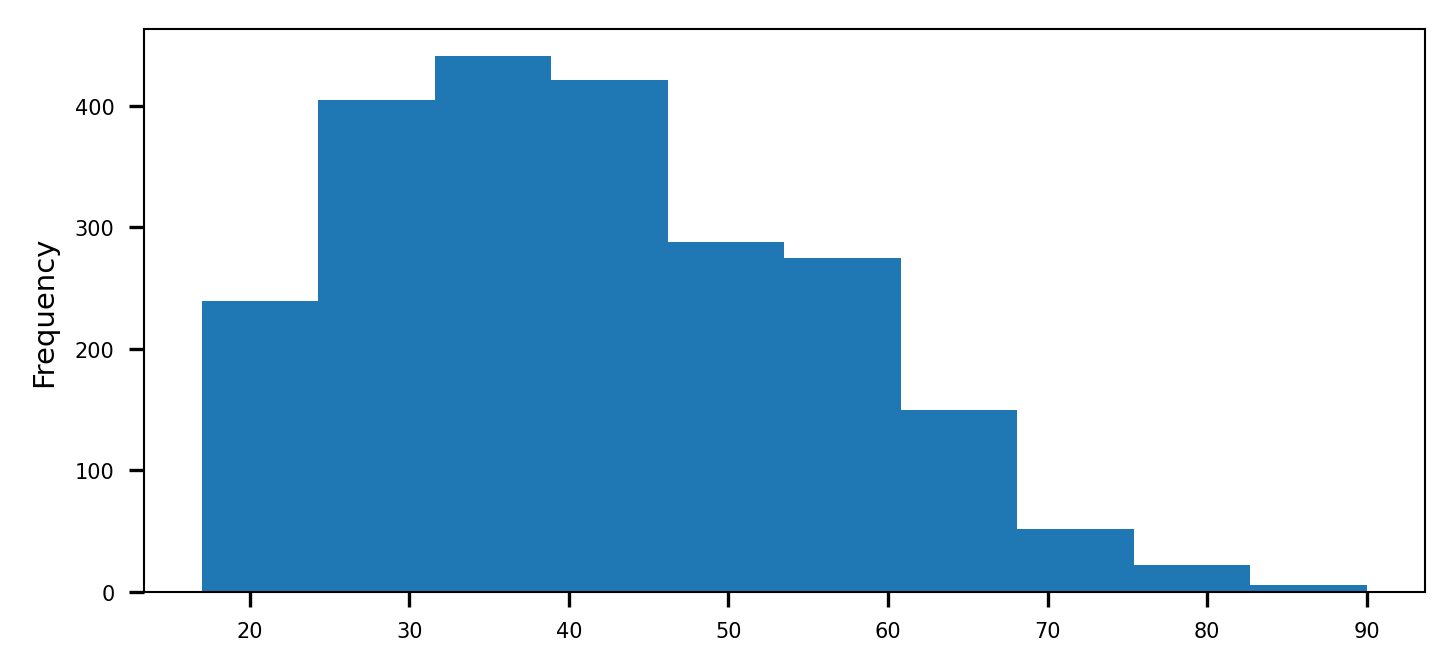

In [24]:
age = voters.loc[voters.representative].loc[voters.age!=' '].age.astype(int)
age.loc[(age<100) & (age>16)].plot.hist()

In [25]:
voters.loc[voters.representative, 'gender'].value_counts()

gender
m       1771
f        532
         112
x         13
none       8
Name: count, dtype: int64